# Selected-model confidence diagnostics

This notebook checks probability validity, reliability, sharpness, confidence–accuracy alignment and seasonal stability for every model contained in a selected-prediction artifact.

In [3]:
from __future__ import annotations

import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression

In [4]:
REPO_ROOT = Path(r"C:\Users\skous\Super-League-odds-research")
DEFAULT_PREDICTIONS = REPO_ROOT / "artifacts" / "scotland_selected_model_evaluation" / "predictions.csv"
PREDICTIONS_PATH = Path(os.environ.get("SCOTLAND_CONFIDENCE_PREDICTIONS", DEFAULT_PREDICTIONS))
SELECTION_DIR = REPO_ROOT / "artifacts" / "scotland_feature_group_selection"
SELECTED_FEATURE_SETS_PATH = SELECTION_DIR / "selected_feature_sets.csv"
SELECTED_FEATURES_PATH = SELECTION_DIR / "selected_features.csv"
OUTPUT_DIR = REPO_ROOT / "artifacts" / "scotland_model_confidence"
IMAGE_DIR = REPO_ROOT / "scotland_research" / "visuals" / "model_confidence"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Use None to analyse every model in the selected-prediction artifact.
MODEL_NAMES = None
MINIMUM_BIN_SIZE = 50
MAXIMUM_BINS = 10
ANALYSIS_LABEL = "selected-feature Scottish development predictions"

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Selected-model predictions were not found at {PREDICTIONS_PATH}. "
        "Generate chronological predictions for the frozen selected specifications first, "
        "or set SCOTLAND_CONFIDENCE_PREDICTIONS to the intended artifact."
    )

PREDICTIONS_PATH, OUTPUT_DIR, IMAGE_DIR

(WindowsPath('C:/Users/skous/Super-League-odds-research/artifacts/scotland_selected_model_evaluation/predictions.csv'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/artifacts/scotland_model_confidence'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence'))

In [5]:
PROBABILITY_COLUMNS = {"H": "prob_H", "D": "prob_D", "A": "prob_A"}
REQUIRED_COLUMNS = {
    "model", "match_id", "season", "result_3way", *PROBABILITY_COLUMNS.values()
}

predictions = pd.read_csv(PREDICTIONS_PATH)
missing_columns = sorted(REQUIRED_COLUMNS.difference(predictions.columns))
if missing_columns:
    raise ValueError(f"Prediction artifact is missing required columns: {missing_columns}")

if MODEL_NAMES is not None:
    missing_models = sorted(set(MODEL_NAMES).difference(predictions["model"].unique()))
    if missing_models:
        raise ValueError(f"Requested models are absent from the artifact: {missing_models}")
    predictions = predictions[predictions["model"].isin(MODEL_NAMES)].copy()

probabilities = predictions[list(PROBABILITY_COLUMNS.values())].to_numpy(dtype=float)
if not np.isfinite(probabilities).all():
    raise ValueError("Prediction probabilities contain non-finite values")
if np.any((probabilities < 0.0) | (probabilities > 1.0)):
    raise ValueError("Prediction probabilities must lie inside [0, 1]")
if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-8):
    raise ValueError("Prediction probabilities do not sum to one")
if predictions["result_3way"].isna().any():
    raise ValueError("Observed outcomes contain missing values")

match_key_columns = ["season", "match_id"]
if predictions.duplicated(["model", *match_key_columns]).any():
    raise ValueError("A model has duplicate predictions for the same match")
reference_model = predictions["model"].iloc[0]
reference_keys = set(map(tuple, predictions.loc[predictions["model"].eq(reference_model), match_key_columns].to_numpy()))
coverage_errors = {}
for model_name, model_rows in predictions.groupby("model"):
    model_keys = set(map(tuple, model_rows[match_key_columns].to_numpy()))
    if model_keys != reference_keys:
        coverage_errors[model_name] = {
            "missing": len(reference_keys.difference(model_keys)),
            "extra": len(model_keys.difference(reference_keys)),
        }
if coverage_errors:
    raise ValueError(f"Models do not cover identical matches: {coverage_errors}")

selected_feature_sets = (
    pd.read_csv(SELECTED_FEATURE_SETS_PATH) if SELECTED_FEATURE_SETS_PATH.exists() else pd.DataFrame()
)
selected_features_table = (
    pd.read_csv(SELECTED_FEATURES_PATH) if SELECTED_FEATURES_PATH.exists() else pd.DataFrame()
)
feature_counts = (
    selected_features_table.groupby("model")["feature"].nunique().to_dict()
    if not selected_features_table.empty else {}
)

coverage_summary = predictions.groupby("model").agg(
    matches=("match_id", "size"),
    seasons=("season", "nunique"),
).reset_index()
coverage_summary

,model,matches,seasons
0,closing_market,665,3
1,dixon_coles_player_form,665,3
2,expanded_player_form_lightgbm,665,3
3,market_plus_player_form,665,3
4,player_form_lightgbm,665,3
5,player_form_logistic,665,3


## Metrics

Reliability bins contain approximately equal numbers of matches. ECE is the observation-weighted absolute calibration gap; MCE is the largest bin gap. Calibration intercept and slope are estimated classwise from the logit of the predicted probability. A slope below one indicates probabilities that are too extreme, while a slope above one indicates probabilities that are too conservative.

In [6]:
def safe_filename(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

def wilson_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1.0 + z**2 / total
    centre = (proportion + z**2 / (2.0 * total)) / denominator
    margin = z * np.sqrt(proportion * (1.0 - proportion) / total + z**2 / (4.0 * total**2)) / denominator
    return max(0.0, centre - margin), min(1.0, centre + margin)

def equal_frequency_bins(values: pd.Series, minimum_size: int = MINIMUM_BIN_SIZE) -> pd.Series:
    bin_count = max(2, min(MAXIMUM_BINS, len(values) // minimum_size))
    return pd.qcut(values.rank(method="first"), q=bin_count, labels=False, duplicates="drop")

def reliability_table(frame: pd.DataFrame, outcome: str) -> pd.DataFrame:
    probability_column = PROBABILITY_COLUMNS[outcome]
    table_data = pd.DataFrame(
        {
            "prediction": frame[probability_column].astype(float),
            "observed": frame["result_3way"].eq(outcome).astype(int),
        },
        index=frame.index,
    )
    table_data["bin"] = equal_frequency_bins(table_data["prediction"])
    rows = []
    for bin_number, group in table_data.groupby("bin", observed=True):
        matches = len(group)
        successes = int(group["observed"].sum())
        lower, upper = wilson_interval(successes, matches)
        average_prediction = float(group["prediction"].mean())
        actual_frequency = successes / matches
        rows.append(
            {
                "outcome": outcome, "bin": int(bin_number), "matches": matches,
                "average_prediction": average_prediction, "actual_frequency": actual_frequency,
                "wilson_lower": lower, "wilson_upper": upper,
                "absolute_gap": abs(actual_frequency - average_prediction),
            }
        )
    return pd.DataFrame(rows)

def calibration_intercept_slope(probability: np.ndarray, observed: np.ndarray) -> tuple[float, float]:
    if np.unique(observed).size < 2:
        return np.nan, np.nan
    clipped = np.clip(probability.astype(float), 1e-6, 1.0 - 1e-6)
    logits = np.log(clipped / (1.0 - clipped)).reshape(-1, 1)
    estimator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000)
    estimator.fit(logits, observed.astype(int))
    return float(estimator.intercept_[0]), float(estimator.coef_[0, 0])

def confidence_table(frame: pd.DataFrame) -> pd.DataFrame:
    matrix = frame[list(PROBABILITY_COLUMNS.values())].to_numpy(dtype=float)
    predicted_index = matrix.argmax(axis=1)
    predicted_outcome = np.array(list(PROBABILITY_COLUMNS))[predicted_index]
    confidence = matrix.max(axis=1)
    data = pd.DataFrame({"confidence": confidence, "correct": predicted_outcome == frame["result_3way"].to_numpy()})
    data["bin"] = equal_frequency_bins(data["confidence"])
    return data.groupby("bin", observed=True).agg(
        matches=("correct", "size"), average_confidence=("confidence", "mean"), accuracy=("correct", "mean")
    ).reset_index()

def model_metrics(frame: pd.DataFrame) -> tuple[dict[str, float], pd.DataFrame, pd.DataFrame]:
    probability_matrix = frame[list(PROBABILITY_COLUMNS.values())].to_numpy(dtype=float)
    outcome_to_index = {outcome: index for index, outcome in enumerate(PROBABILITY_COLUMNS)}
    actual_indexes = frame["result_3way"].map(outcome_to_index).to_numpy(dtype=int)
    one_hot = np.eye(len(PROBABILITY_COLUMNS))[actual_indexes]
    reliability = pd.concat([reliability_table(frame, outcome) for outcome in PROBABILITY_COLUMNS], ignore_index=True)
    class_ece = reliability.groupby("outcome").apply(
        lambda table: float(np.average(table["absolute_gap"], weights=table["matches"])),
        include_groups=False,
    )
    metrics = {
        "matches": len(frame),
        "log_loss": float(-np.log(np.clip(probability_matrix[np.arange(len(frame)), actual_indexes], 1e-15, 1.0)).mean()),
        "brier_score": float(np.square(probability_matrix - one_hot).sum(axis=1).mean()),
        "accuracy": float((probability_matrix.argmax(axis=1) == actual_indexes).mean()),
        "ece": float(class_ece.mean()),
        "mce": float(reliability["absolute_gap"].max()),
        "mean_max_probability": float(probability_matrix.max(axis=1).mean()),
    }
    for outcome, probability_column in PROBABILITY_COLUMNS.items():
        observed = frame["result_3way"].eq(outcome).to_numpy(dtype=int)
        intercept, slope = calibration_intercept_slope(frame[probability_column].to_numpy(), observed)
        metrics[f"ece_{outcome}"] = float(class_ece.loc[outcome])
        metrics[f"calibration_intercept_{outcome}"] = intercept
        metrics[f"calibration_slope_{outcome}"] = slope
    metrics["mean_calibration_slope"] = float(np.nanmean([metrics[f"calibration_slope_{outcome}"] for outcome in PROBABILITY_COLUMNS]))
    return metrics, reliability, confidence_table(frame)

In [7]:
overall_rows = []
seasonal_rows = []
reliability_frames = []
confidence_frames = []

for model_name, model_rows in predictions.groupby("model", sort=False):
    metrics, reliability, confidence = model_metrics(model_rows)
    overall_rows.append({"model": model_name, **metrics})
    reliability.insert(0, "model", model_name)
    confidence.insert(0, "model", model_name)
    reliability_frames.append(reliability)
    confidence_frames.append(confidence)
    for season, season_rows in model_rows.groupby("season", sort=False):
        season_metrics, _, _ = model_metrics(season_rows)
        seasonal_rows.append({"model": model_name, "season": season, **season_metrics})

overall_metrics = pd.DataFrame(overall_rows).sort_values("log_loss").reset_index(drop=True)
seasonal_metrics = pd.DataFrame(seasonal_rows)
reliability_bins = pd.concat(reliability_frames, ignore_index=True)
confidence_bins = pd.concat(confidence_frames, ignore_index=True)

overall_metrics[["model", "matches", "log_loss", "brier_score", "accuracy", "ece", "mce", "mean_calibration_slope", "mean_max_probability"]]

,model,matches,log_loss,brier_score,accuracy,ece,mce,mean_calibration_slope,mean_max_probability
0,closing_market,665,0.917761,0.538017,0.568421,0.043114,0.129057,1.151298,0.543915
1,market_plus_player_form,665,0.921457,0.537396,0.580451,0.040379,0.117931,0.869132,0.569800
2,dixon_coles_player_form,665,0.934620,0.549785,0.574436,0.046272,0.150429,0.937573,0.547540
3,player_form_logistic,665,0.939640,0.552549,0.553383,0.046583,0.115198,0.984103,0.549568
4,expanded_player_form_lightgbm,665,0.943369,0.553742,0.565414,0.053980,0.207593,0.785013,0.561470
5,player_form_lightgbm,665,0.945419,0.557784,0.539850,0.047851,0.168723,0.868472,0.565723


In [8]:
seasonal_stability = seasonal_metrics.groupby("model").agg(
    mean_season_log_loss=("log_loss", "mean"),
    worst_season_log_loss=("log_loss", "max"),
    season_log_loss_sd=("log_loss", "std"),
    mean_season_ece=("ece", "mean"),
    worst_season_ece=("ece", "max"),
).reset_index().sort_values("mean_season_log_loss")
seasonal_stability

,model,mean_season_log_loss,worst_season_log_loss,season_log_loss_sd,mean_season_ece,worst_season_ece
0,closing_market,0.917908,0.954097,0.041793,0.053724,0.066485
3,market_plus_player_form,0.921593,0.960808,0.044583,0.051580,0.072586
1,dixon_coles_player_form,0.934757,0.971072,0.041635,0.054178,0.068887
5,player_form_logistic,0.939728,0.966475,0.030241,0.052386,0.076745
2,expanded_player_form_lightgbm,0.943718,0.972647,0.041538,0.060539,0.083418
4,player_form_lightgbm,0.945701,0.974571,0.038990,0.054176,0.064929


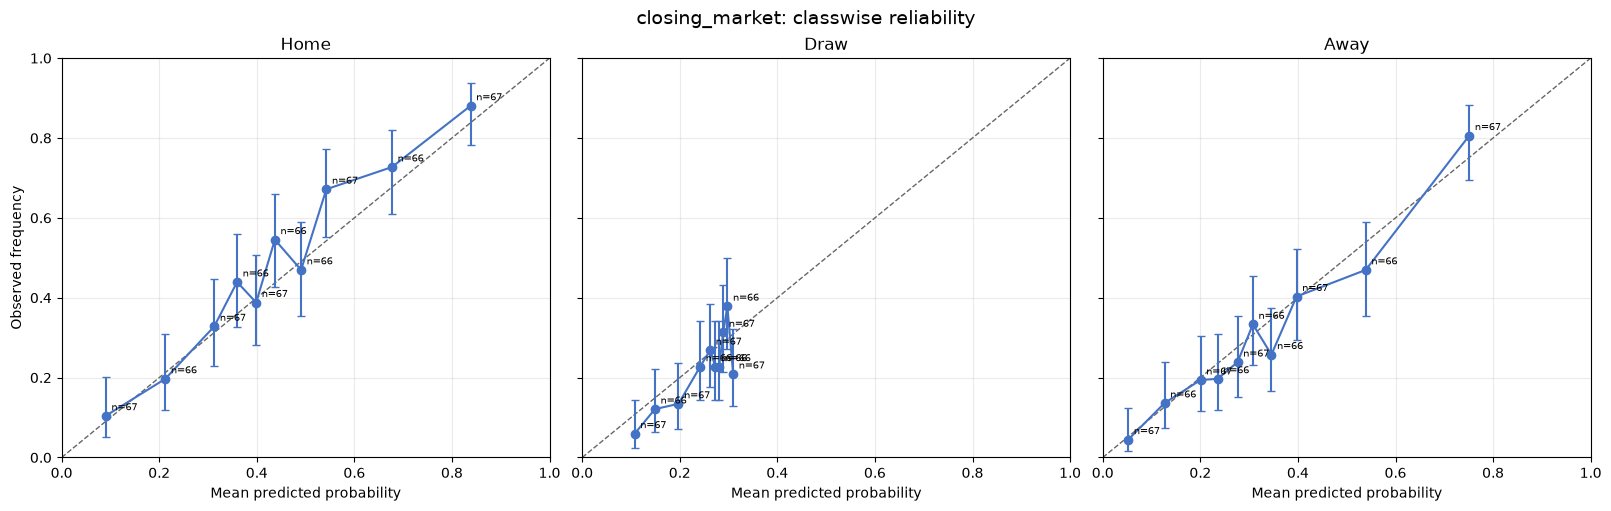

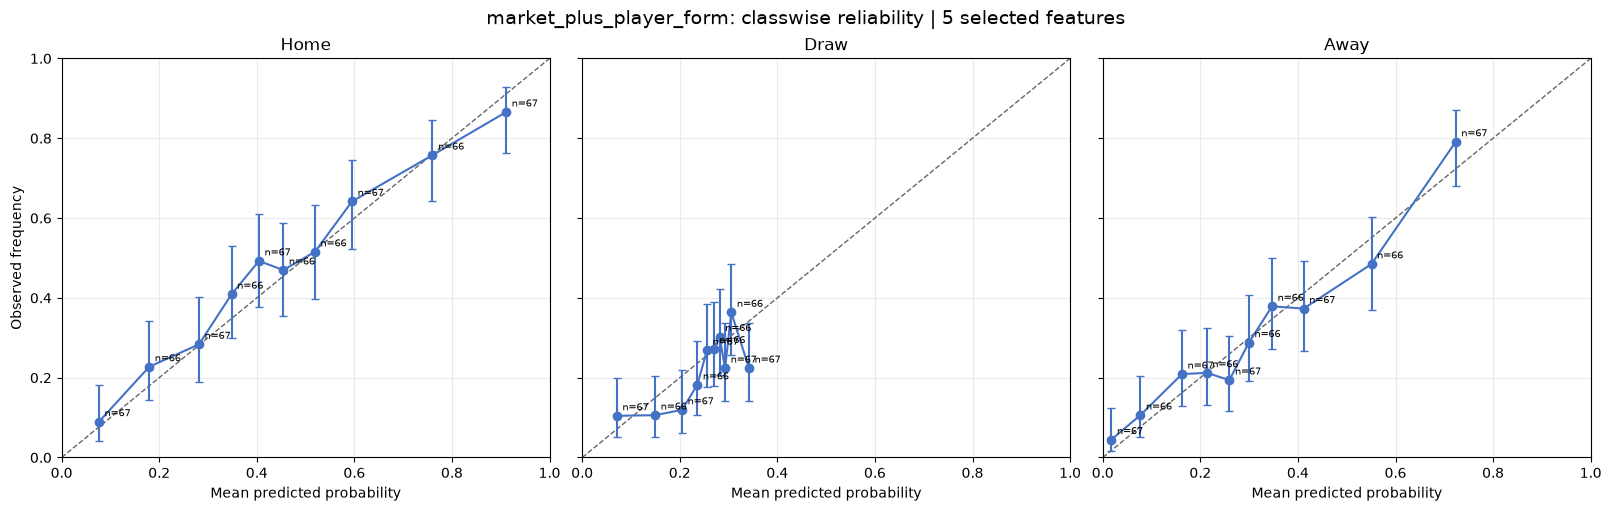

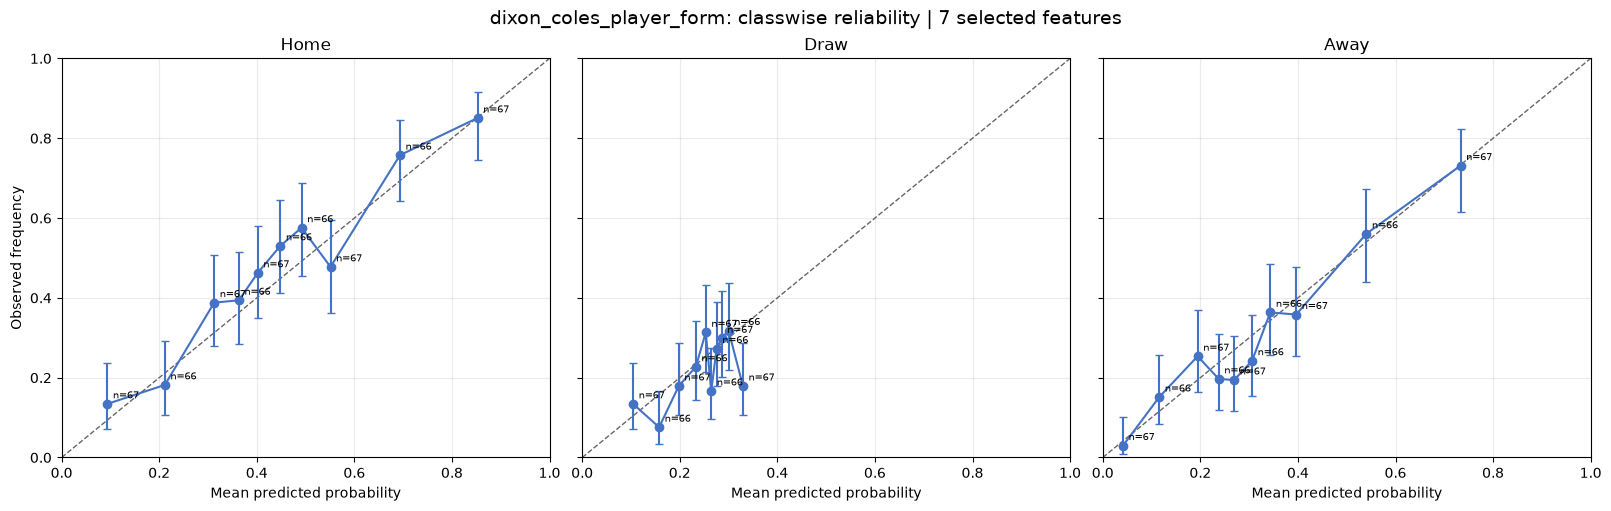

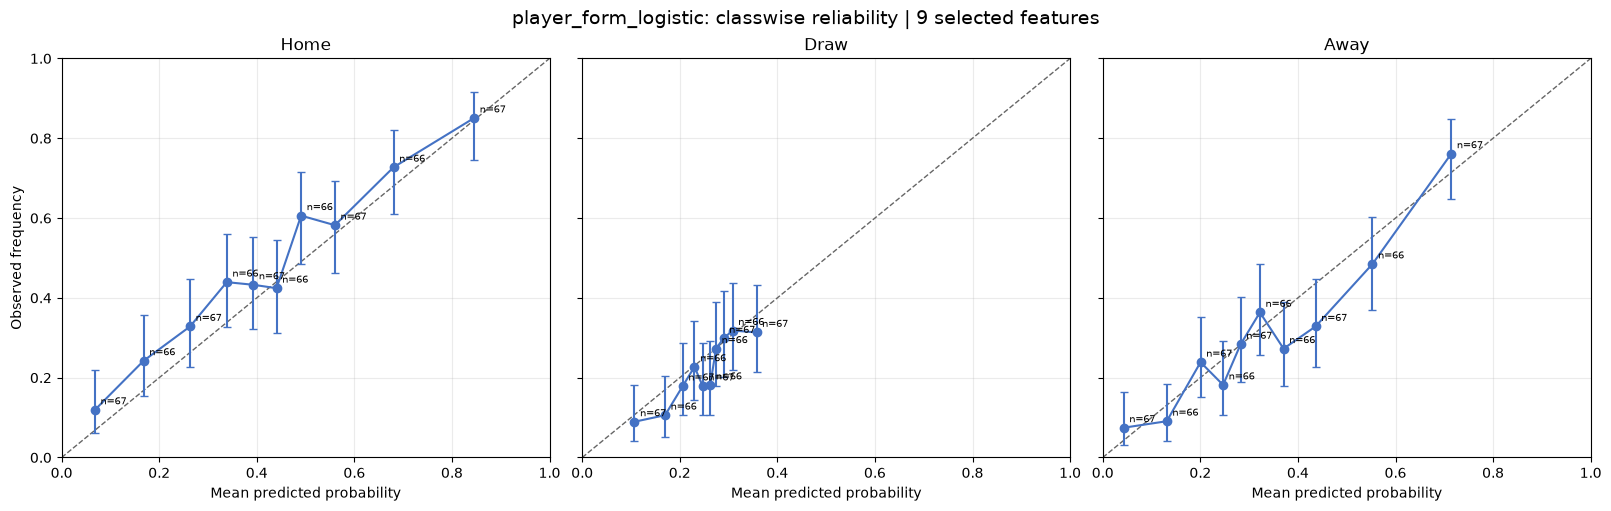

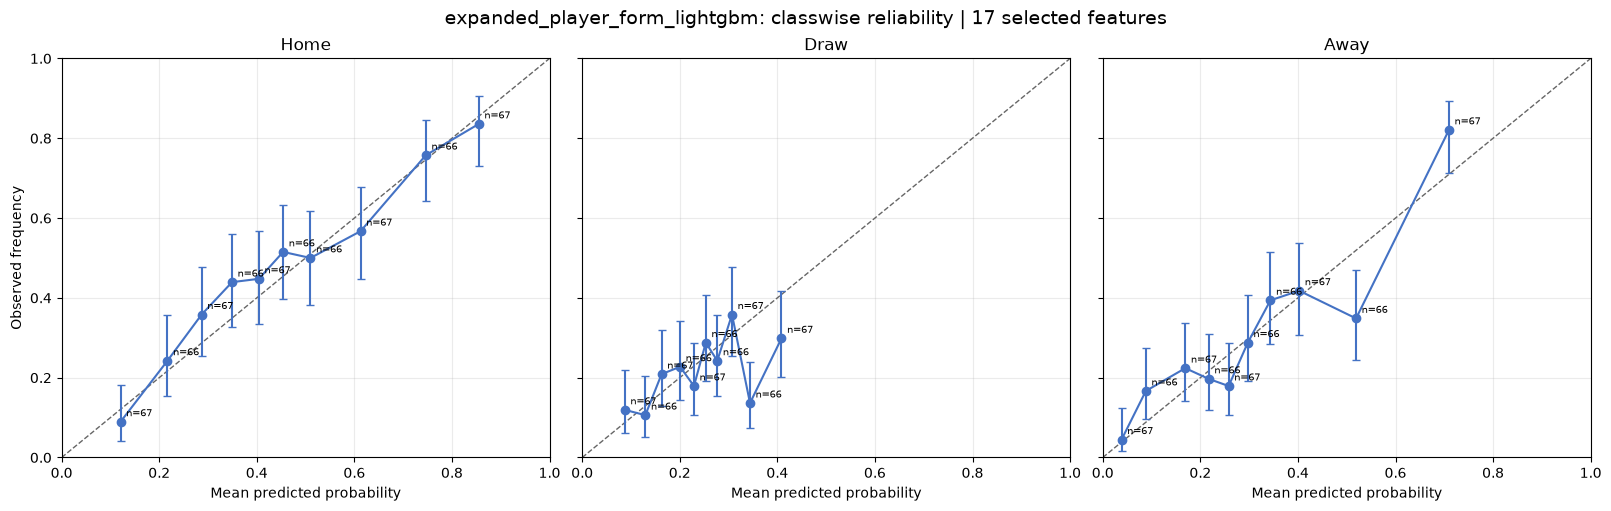

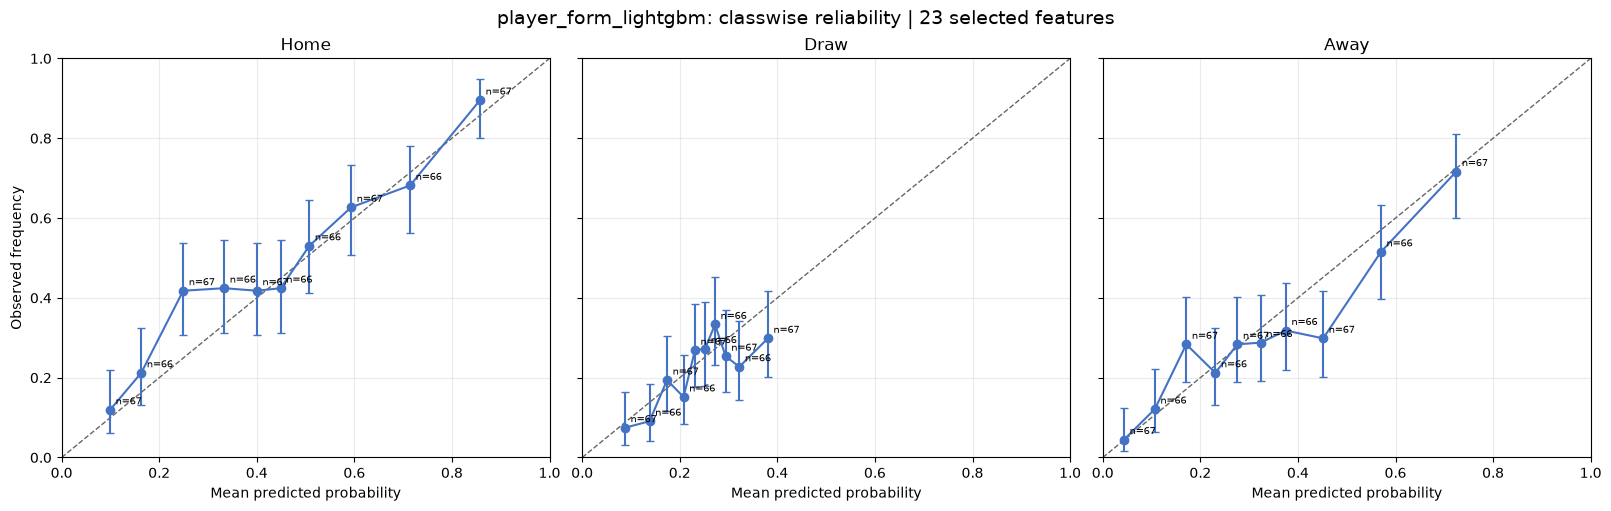

[WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/closing_market_reliability.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/market_plus_player_form_reliability.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/dixon_coles_player_form_reliability.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/player_form_logistic_reliability.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/expanded_player_form_lightgbm_reliability.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/player_form_lightgbm_reliability.png')]

In [9]:
plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})
reliability_images = []

for model_name in overall_metrics["model"]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True, constrained_layout=True)
    for axis, outcome in zip(axes, PROBABILITY_COLUMNS, strict=True):
        table = reliability_bins[reliability_bins["model"].eq(model_name) & reliability_bins["outcome"].eq(outcome)]
        lower_error = table["actual_frequency"] - table["wilson_lower"]
        upper_error = table["wilson_upper"] - table["actual_frequency"]
        axis.plot([0, 1], [0, 1], linestyle="--", color="#666666", linewidth=1)
        axis.errorbar(
            table["average_prediction"], table["actual_frequency"],
            yerr=np.vstack([lower_error, upper_error]), marker="o", color="#4472C4",
            linewidth=1.5, capsize=3,
        )
        for row in table.itertuples(index=False):
            axis.annotate(f"n={row.matches}", (row.average_prediction, row.actual_frequency), xytext=(4, 4), textcoords="offset points", fontsize=7)
        axis.set_title({"H": "Home", "D": "Draw", "A": "Away"}[outcome])
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.set_xlabel("Mean predicted probability")
        axis.grid(alpha=0.25)
    axes[0].set_ylabel("Observed frequency")
    feature_count = feature_counts.get(model_name)
    feature_text = f" | {feature_count} selected features" if feature_count is not None else ""
    fig.suptitle(f"{model_name}: classwise reliability{feature_text}", fontsize=14)
    image_path = IMAGE_DIR / f"{safe_filename(model_name)}_reliability.png"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    reliability_images.append(image_path)
    plt.show()
    plt.close(fig)

reliability_images

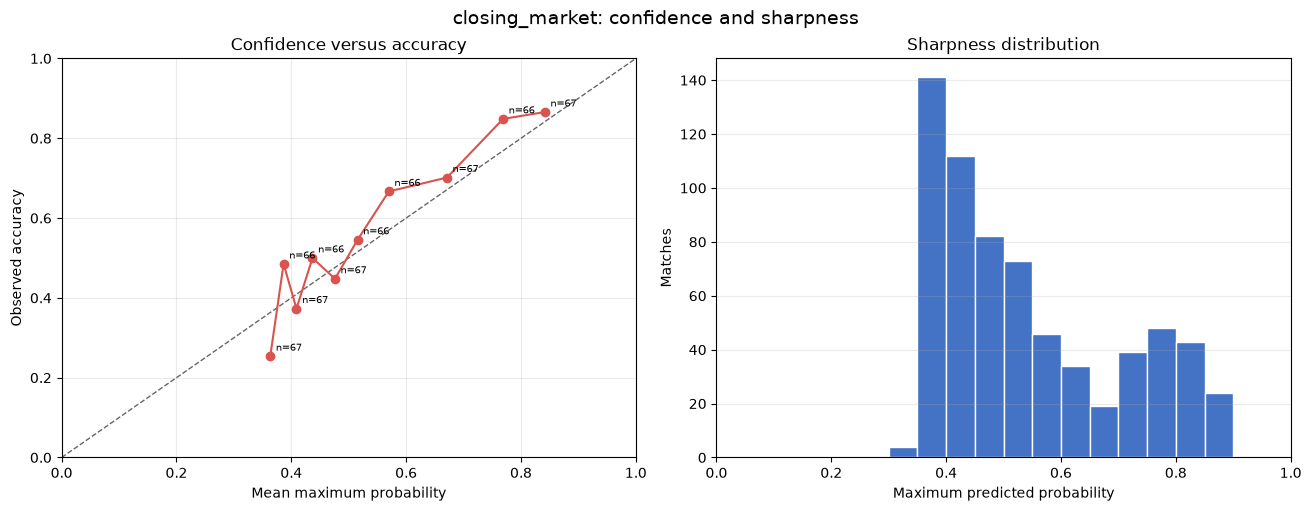

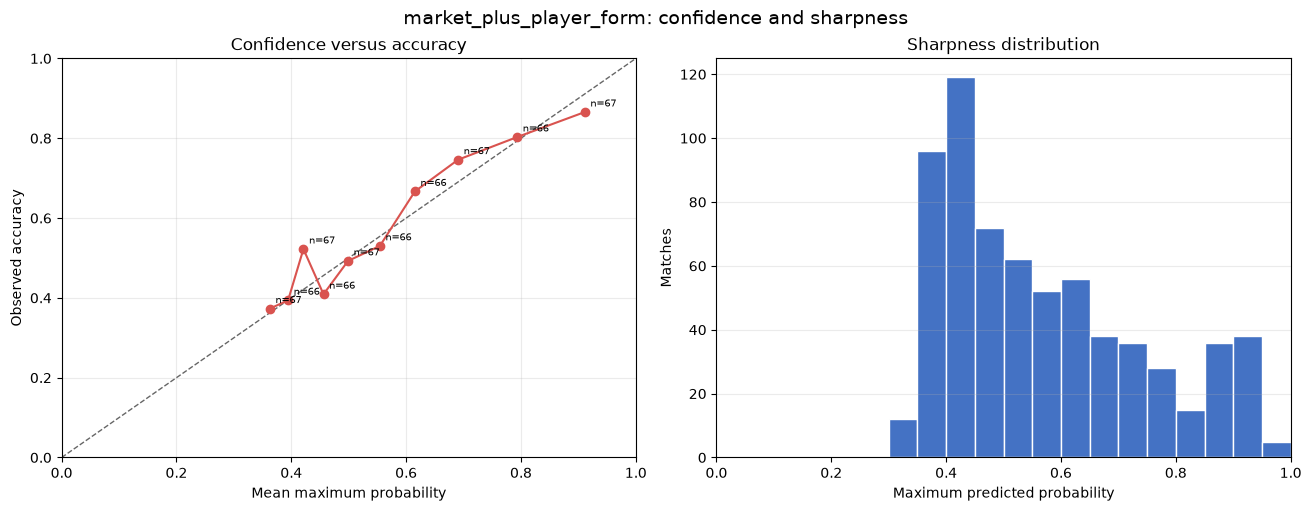

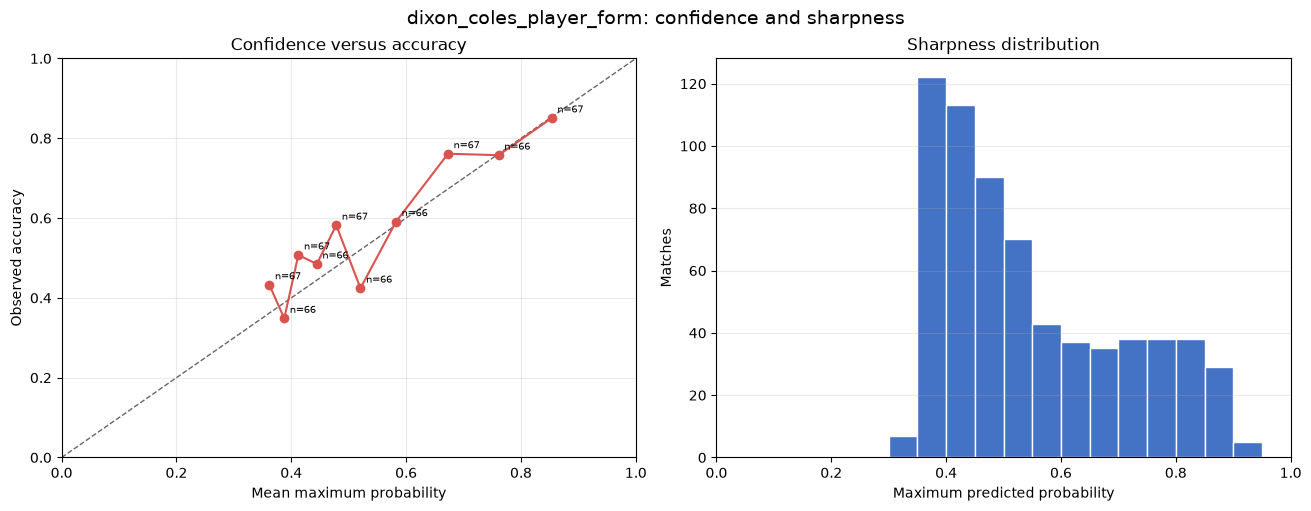

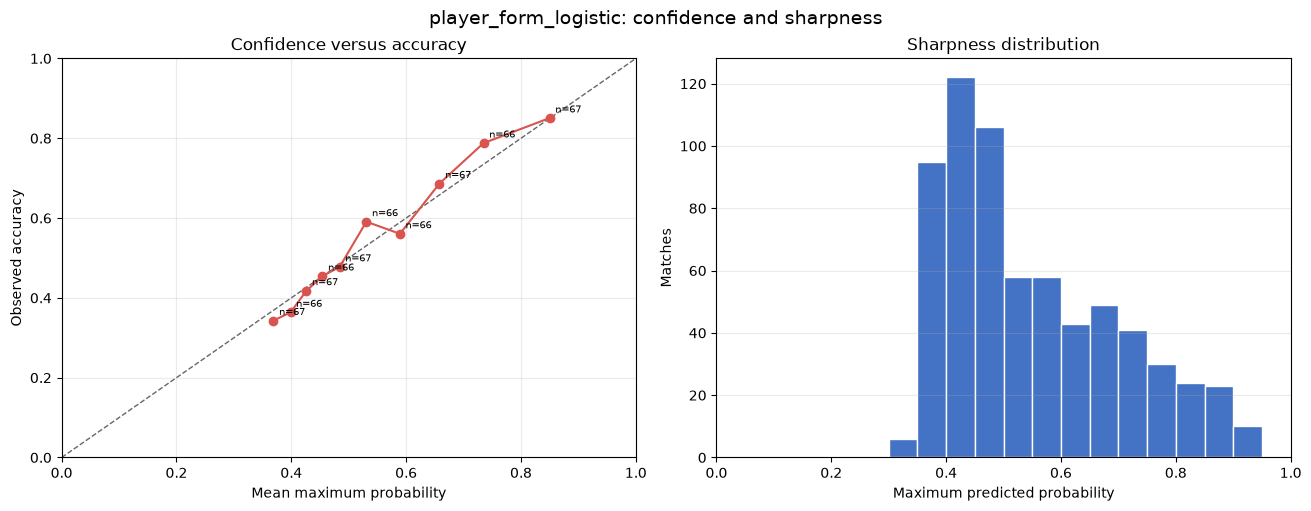

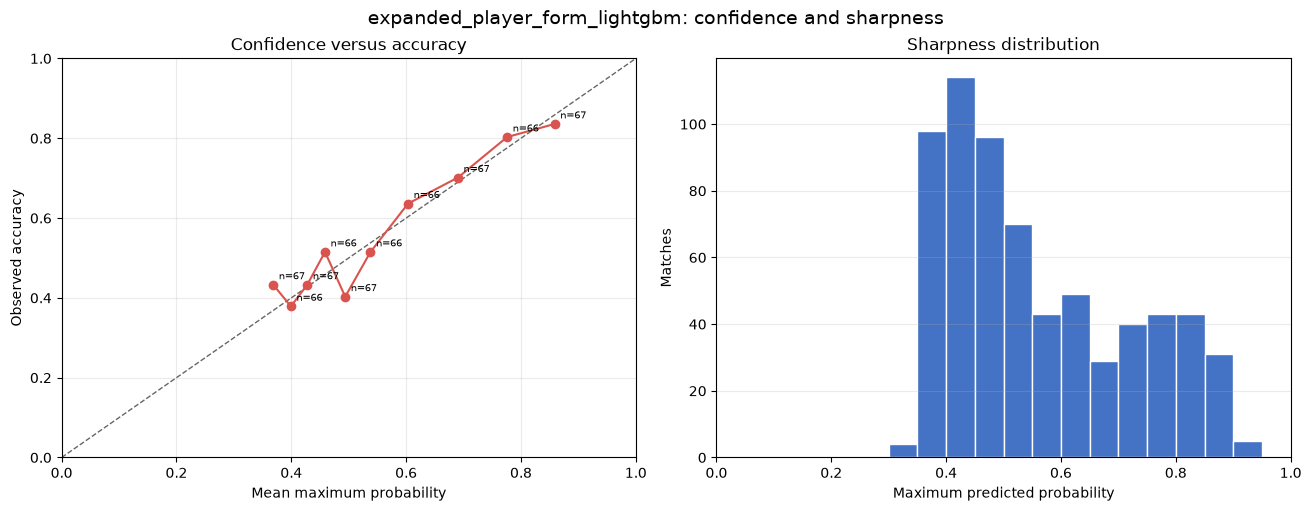

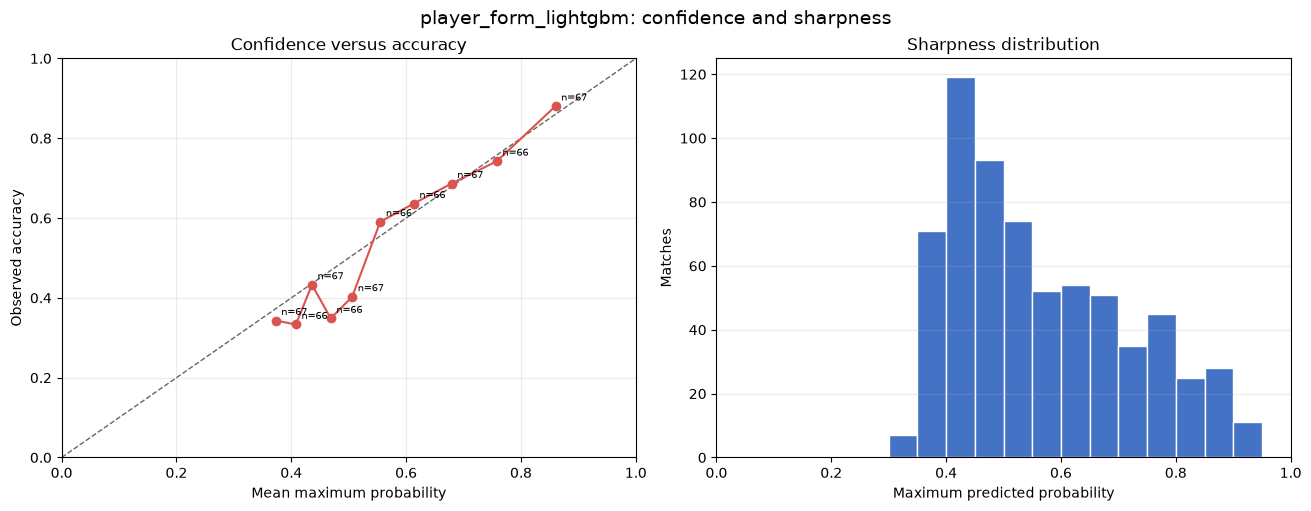

[WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/closing_market_confidence_accuracy.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/market_plus_player_form_confidence_accuracy.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/dixon_coles_player_form_confidence_accuracy.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/player_form_logistic_confidence_accuracy.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/expanded_player_form_lightgbm_confidence_accuracy.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/player_form_lightgbm_confidence_accuracy.png')]

In [10]:
confidence_images = []
for model_name in overall_metrics["model"]:
    model_rows = predictions[predictions["model"].eq(model_name)]
    matrix = model_rows[list(PROBABILITY_COLUMNS.values())].to_numpy(dtype=float)
    maximum_probability = matrix.max(axis=1)
    table = confidence_bins[confidence_bins["model"].eq(model_name)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="#666666", linewidth=1)
    axes[0].plot(table["average_confidence"], table["accuracy"], marker="o", color="#D9534F")
    for row in table.itertuples(index=False):
        axes[0].annotate(f"n={row.matches}", (row.average_confidence, row.accuracy), xytext=(4, 4), textcoords="offset points", fontsize=7)
    axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean maximum probability", ylabel="Observed accuracy", title="Confidence versus accuracy")
    axes[0].grid(alpha=0.25)
    axes[1].hist(maximum_probability, bins=np.linspace(0, 1, 21), color="#4472C4", edgecolor="white")
    axes[1].set(xlim=(0, 1), xlabel="Maximum predicted probability", ylabel="Matches", title="Sharpness distribution")
    axes[1].grid(axis="y", alpha=0.25)
    fig.suptitle(f"{model_name}: confidence and sharpness", fontsize=14)
    image_path = IMAGE_DIR / f"{safe_filename(model_name)}_confidence_accuracy.png"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    confidence_images.append(image_path)
    plt.show()
    plt.close(fig)

confidence_images

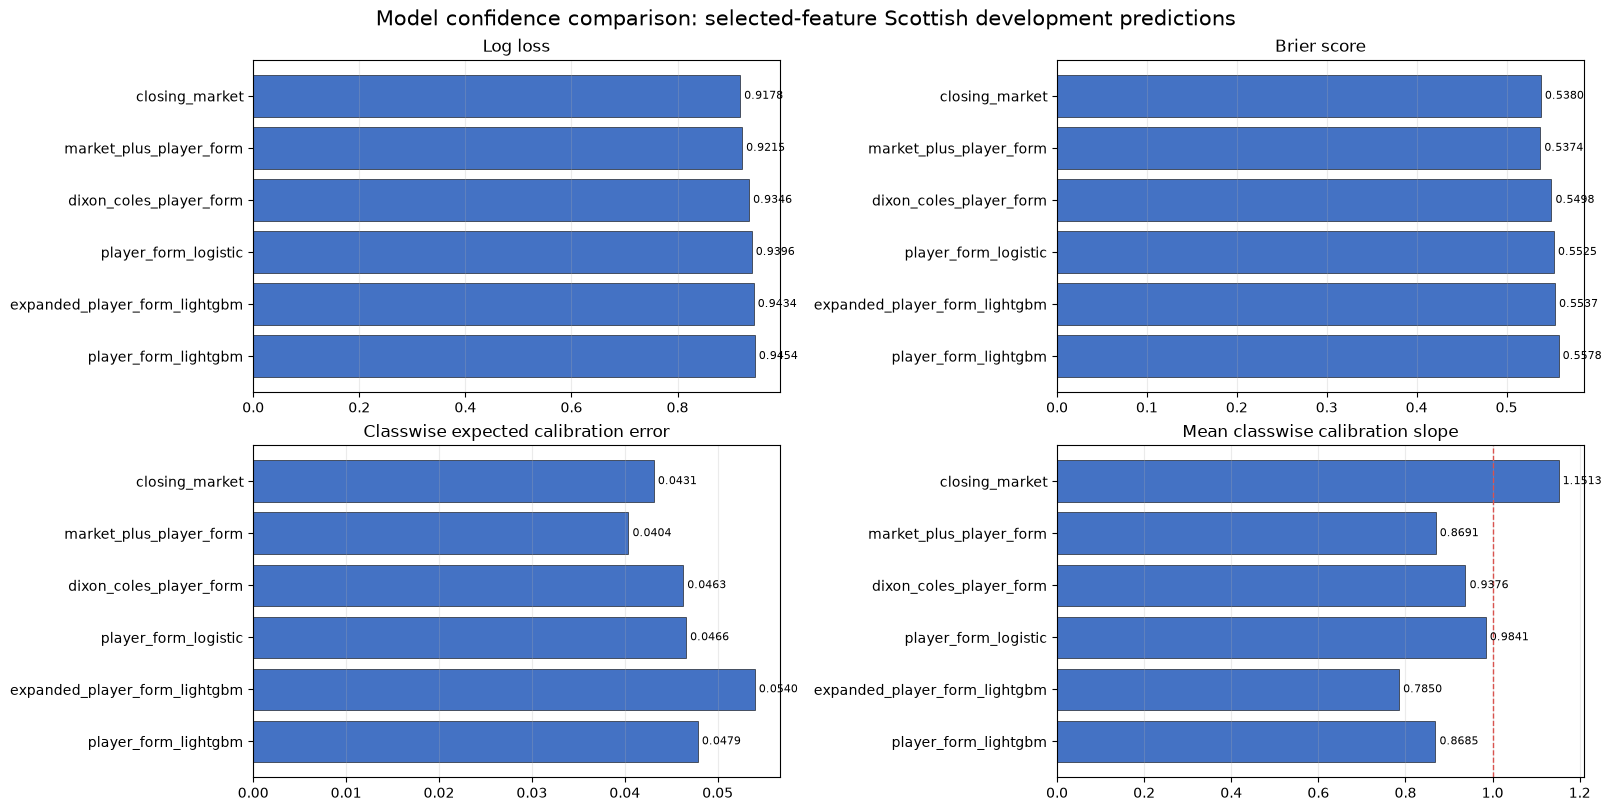

WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/model_confidence/selected_models_confidence_comparison.png')

In [11]:
comparison = overall_metrics.sort_values("log_loss", ascending=False).copy()
fig, axes = plt.subplots(2, 2, figsize=(16, max(8, 0.55 * len(comparison))), constrained_layout=True)
panels = [
    ("log_loss", "Log loss", None),
    ("brier_score", "Brier score", None),
    ("ece", "Classwise expected calibration error", None),
    ("mean_calibration_slope", "Mean classwise calibration slope", 1.0),
]
for axis, (column, title, reference) in zip(axes.ravel(), panels, strict=True):
    bars = axis.barh(comparison["model"], comparison[column], color="#4472C4", edgecolor="black", linewidth=0.4)
    axis.bar_label(bars, labels=[f"{value:.4f}" for value in comparison[column]], padding=3, fontsize=8)
    if reference is not None:
        axis.axvline(reference, color="#D9534F", linestyle="--", linewidth=1)
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.25)
fig.suptitle(f"Model confidence comparison: {ANALYSIS_LABEL}", fontsize=15)
comparison_path = IMAGE_DIR / "selected_models_confidence_comparison.png"
fig.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
comparison_path

In [12]:
overall_metrics.to_csv(OUTPUT_DIR / "confidence_metrics_overall.csv", index=False)
seasonal_metrics.to_csv(OUTPUT_DIR / "confidence_metrics_by_season.csv", index=False)
seasonal_stability.to_csv(OUTPUT_DIR / "confidence_seasonal_stability.csv", index=False)
reliability_bins.to_csv(OUTPUT_DIR / "reliability_bins.csv", index=False)
confidence_bins.to_csv(OUTPUT_DIR / "confidence_accuracy_bins.csv", index=False)
coverage_summary.to_csv(OUTPUT_DIR / "prediction_coverage.csv", index=False)
print(f"Saved confidence tables to {OUTPUT_DIR}")
print(f"Saved {len(reliability_images) + len(confidence_images) + 1} confidence images to {IMAGE_DIR}")

Saved confidence tables to C:\Users\skous\Super-League-odds-research\artifacts\scotland_model_confidence
Saved 13 confidence images to C:\Users\skous\Super-League-odds-research\scotland_research\visuals\model_confidence


# Results

On selected-feature Scottish development predictions, closing_market has the lowest log loss (0.9178), while market_plus_player_form has the lowest classwise ECE (0.0404). player_form_logistic has the smallest seasonal log-loss standard deviation (0.0302). These rankings are descriptive development results; they do not establish generalization after feature selection or prove that post-hoc calibration will help.